<a href="https://colab.research.google.com/github/dulaksha-chathura/EN3160-Assignment-1-on-Intensity-Transformations-and-Neighborhood-Filtering/blob/main/230100M_a01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EN3160 Assignment 01 - Question 1
**Index Number:** 230100M
**Name:** Chandrakumara H.A.D.C.
**GitHub:** https://github.com/dulaksha-chathura/EN3160-Assignment-1-on-Intensity-Transformations-and-Neighborhood-Filtering

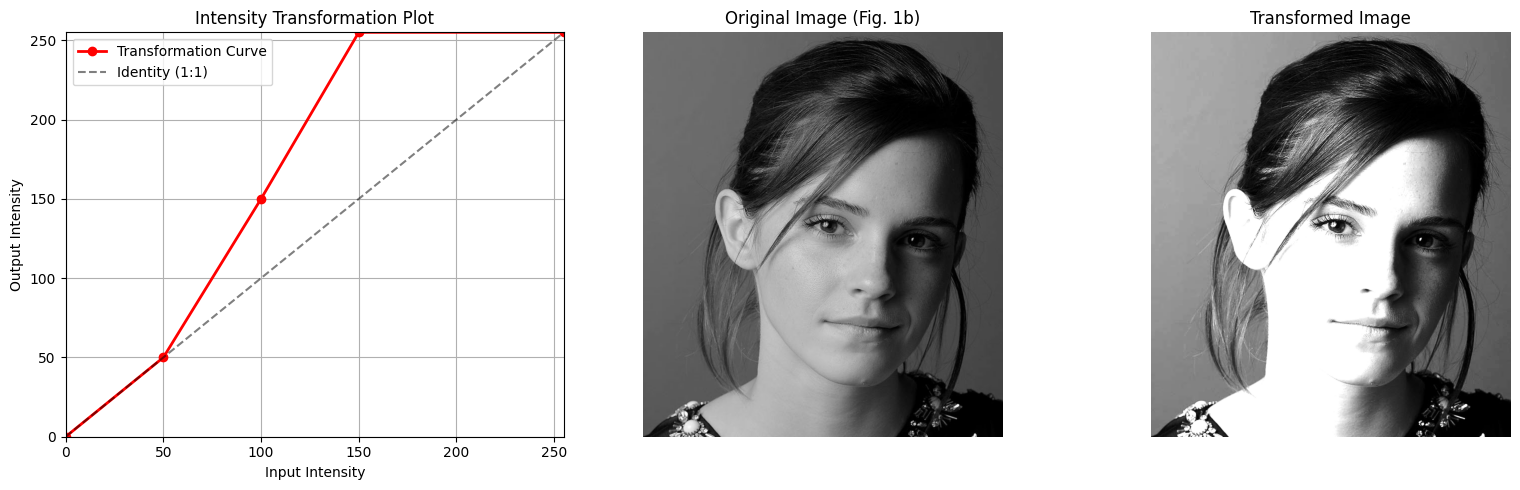

In [13]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# ---------------------------------------------------------
# 1. Function Definition for Piecewise Linear Intensity Transformation
# ---------------------------------------------------------


def intensity_transform(im, breakpoints):
    """Applies piecewise linear intensity transformation based on given breakpoints.

    breakpoints: Nx2 list/array of [input_intensity, output_intensity] pairs.
    """
    # Ensure breakpoints are sorted by input intensity (x-axis)
    breakpoints = np.array(sorted(breakpoints, key=lambda x: x[0]))

    xp = breakpoints[:, 0]  # Input intensity coordinates
    fp = breakpoints[:, 1]  # Output intensity coordinates

    # Compute lookup table (LUT) using linear interpolation across [0, 255]
    lut = np.interp(np.arange(256), xp, fp).astype(np.uint8)

    # Apply lookup table transformation to image
    transformed_im = cv2.LUT(im, lut)

    return transformed_im, xp, fp


# ---------------------------------------------------------
# 2. Load the Input Image
# ---------------------------------------------------------
# Replace 'q1.jpeg' with the exact filename you uploaded to Colab
image_path = "q1.jpeg"

img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Sanity check to confirm image is loaded properly
if img is None:
    print(
        f"Error: Could not find '{image_path}'. Please upload it to Colab's file sidebar."
    )
else:
    # ---------------------------------------------------------
    # 3. Define Breakpoints (Given in Q1 specification)
    # ---------------------------------------------------------
    breakpoints = [[0, 0], [50, 50], [100, 150], [150, 255], [255, 255]]

    # Apply transformation
    transformed_img, x_pts, y_pts = intensity_transform(img, breakpoints)

    # ---------------------------------------------------------
    # 4. Display Results (Transformation Plot + Side-by-Side Images)
    # ---------------------------------------------------------
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # Plot 1: Intensity Transformation Plot
    axes[0].plot(x_pts, y_pts, "r-o", linewidth=2, label="Transformation Curve")
    axes[0].plot([0, 255], [0, 255], "k--", alpha=0.5, label="Identity (1:1)")
    axes[0].set_title("Intensity Transformation Plot")
    axes[0].set_xlabel("Input Intensity")
    axes[0].set_ylabel("Output Intensity")
    axes[0].set_xlim([0, 255])
    axes[0].set_ylim([0, 255])
    axes[0].grid(True)
    axes[0].legend()

    # Plot 2: Original Image
    axes[1].imshow(img, cmap="gray", vmin=0, vmax=255)
    axes[1].set_title("Original Image (Fig. 1b)")
    axes[1].axis("off")

    # Plot 3: Transformed Image
    axes[2].imshow(transformed_img, cmap="gray", vmin=0, vmax=255)
    axes[2].set_title("Transformed Image")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

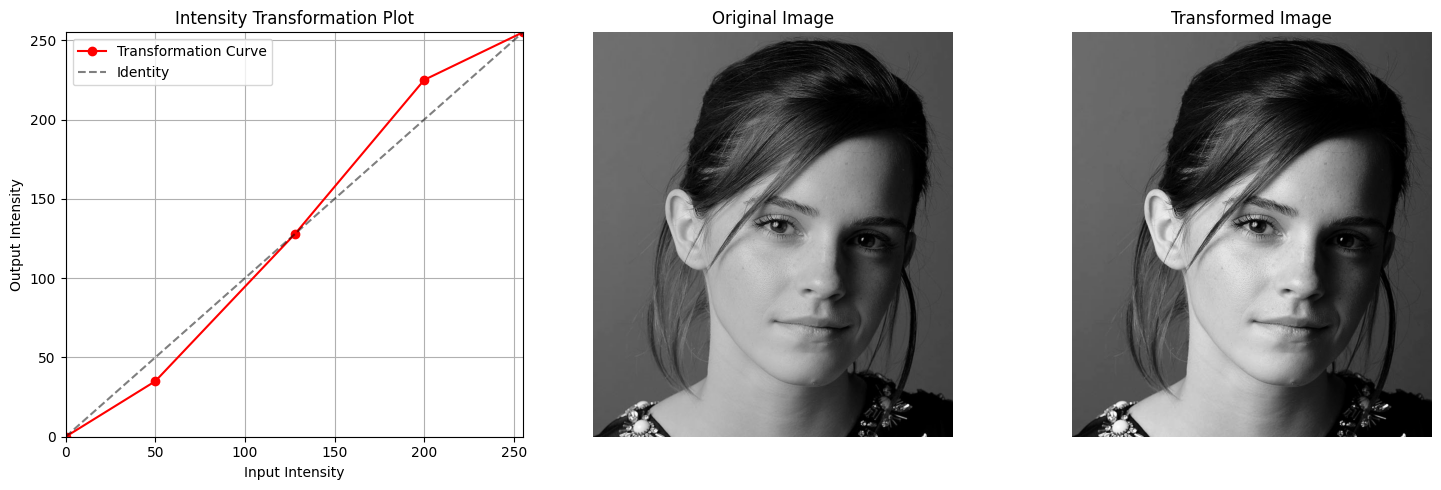

In [14]:
import cv2
import matplotlib.pyplot as plt
import numpy as np


def intensity_transform(im, breakpoints):
    bp = np.array(sorted(breakpoints, key=lambda x: x[0]))
    lut = np.interp(np.arange(256), bp[:, 0], bp[:, 1]).astype(np.uint8)
    return cv2.LUT(im, lut), bp[:, 0], bp[:, 1]


img = cv2.imread("q1.jpeg", cv2.IMREAD_GRAYSCALE)
breakpoints = [[0, 0], [50, 35], [128, 128], [200, 225], [255, 255]]

transformed_img, x_pts, y_pts = intensity_transform(img, breakpoints)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].plot(x_pts, y_pts, "r-o", label="Transformation Curve")
axes[0].plot([0, 255], [0, 255], "k--", alpha=0.5, label="Identity")
axes[0].set_title("Intensity Transformation Plot")
axes[0].set_xlabel("Input Intensity")
axes[0].set_ylabel("Output Intensity")
axes[0].set_xlim([0, 255])
axes[0].set_ylim([0, 255])
axes[0].grid(True)
axes[0].legend()

axes[1].imshow(img, cmap="gray", vmin=0, vmax=255)
axes[1].set_title("Original Image")
axes[1].axis("off")

axes[2].imshow(transformed_img, cmap="gray", vmin=0, vmax=255)
axes[2].set_title("Transformed Image")
axes[2].axis("off")

plt.tight_layout()
plt.show()

## Question 2: Accentuation of White Matter and Gray Matter in Brain MRI
In this task, piecewise-linear intensity transformations are applied to accentuate specific tissue regions in a brain proton density MRI slice[cite: 2]:
* **White Matter:** Represented by bright intensity values (~180–255 range).
* **Gray Matter:** Represented by intermediate intensity values (~100–170 range).

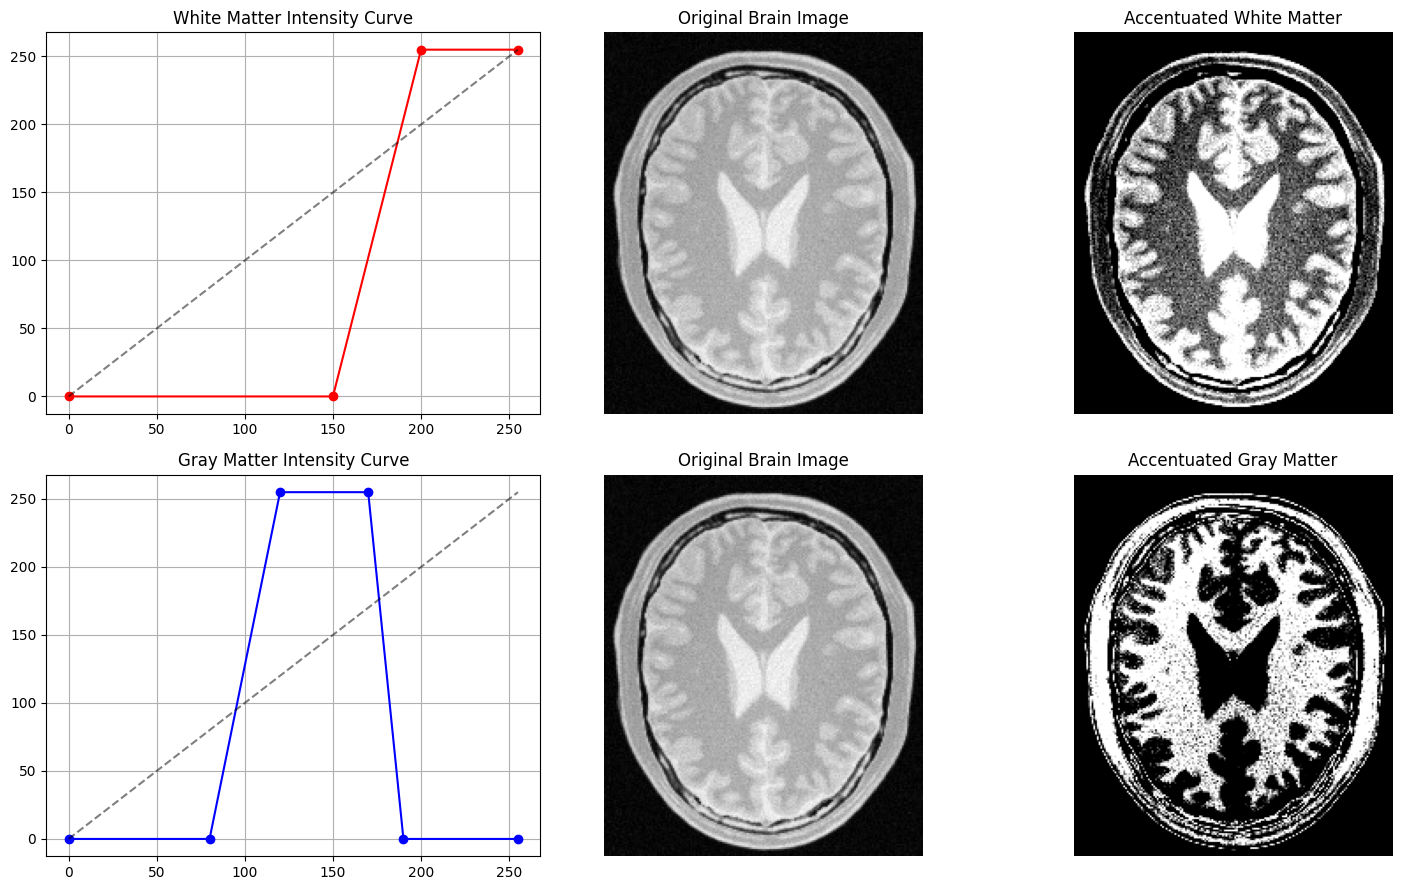

In [15]:
import cv2
import matplotlib.pyplot as plt
import numpy as np


def intensity_transform(im, breakpoints):
    bp = np.array(sorted(breakpoints, key=lambda x: x[0]))
    lut = np.interp(np.arange(256), bp[:, 0], bp[:, 1]).astype(np.uint8)
    return cv2.LUT(im, lut), bp[:, 0], bp[:, 1]


# Load brain image
img_brain = cv2.imread("q2.jpeg", cv2.IMREAD_GRAYSCALE)

# Breakpoints to accentuate White Matter (suppress mid/dark, boost high intensities)
bp_wm = [[0, 0], [150, 0], [200, 255], [255, 255]]
wm_img, x_wm, y_wm = intensity_transform(img_brain, bp_wm)

# Breakpoints to accentuate Gray Matter (isolate mid-intensity range)
bp_gm = [[0, 0], [80, 0], [120, 255], [170, 255], [190, 0], [255, 0]]
gm_img, x_gm, y_gm = intensity_transform(img_brain, bp_gm)

# Visualization
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# White Matter Plot & Image
axes[0, 0].plot(x_wm, y_wm, "r-o", label="Transformation")
axes[0, 0].plot([0, 255], [0, 255], "k--", alpha=0.5)
axes[0, 0].set_title("White Matter Intensity Curve")
axes[0, 0].grid(True)

axes[0, 1].imshow(img_brain, cmap="gray")
axes[0, 1].set_title("Original Brain Image")
axes[0, 1].axis("off")

axes[0, 2].imshow(wm_img, cmap="gray")
axes[0, 2].set_title("Accentuated White Matter")
axes[0, 2].axis("off")

# Gray Matter Plot & Image
axes[1, 0].plot(x_gm, y_gm, "b-o", label="Transformation")
axes[1, 0].plot([0, 255], [0, 255], "k--", alpha=0.5)
axes[1, 0].set_title("Gray Matter Intensity Curve")
axes[1, 0].grid(True)

axes[1, 1].imshow(img_brain, cmap="gray")
axes[1, 1].set_title("Original Brain Image")
axes[1, 1].axis("off")

axes[1, 2].imshow(gm_img, cmap="gray")
axes[1, 2].set_title("Accentuated Gray Matter")
axes[1, 2].axis("off")

plt.tight_layout()
plt.show()

### Discussion & Interpretation:
* **White Matter Accentuation:** Setting output intensities to 0 for inputs below 150 effectively eliminates background and gray matter, highlighting the white matter tracts near the center and cortical regions.
* **Gray Matter Accentuation:** Band-pass thresholding (mapping 120–170 input range to high brightness and suppressing both dark background and bright white matter) isolates the cerebral cortex gray matter.

## Question 3: Gamma Correction on $L^*$ Plane in $L^*a^*b^*$ Color Space
Applying power-law (Gamma) correction directly to the $L^*$ (Luminance) channel adjusts perception of brightness without altering color hue or saturation[cite: 2].

Formula:
$$L_{out} = 255 \times \left(\frac{L_{in}}{255}\right)^\gamma$$

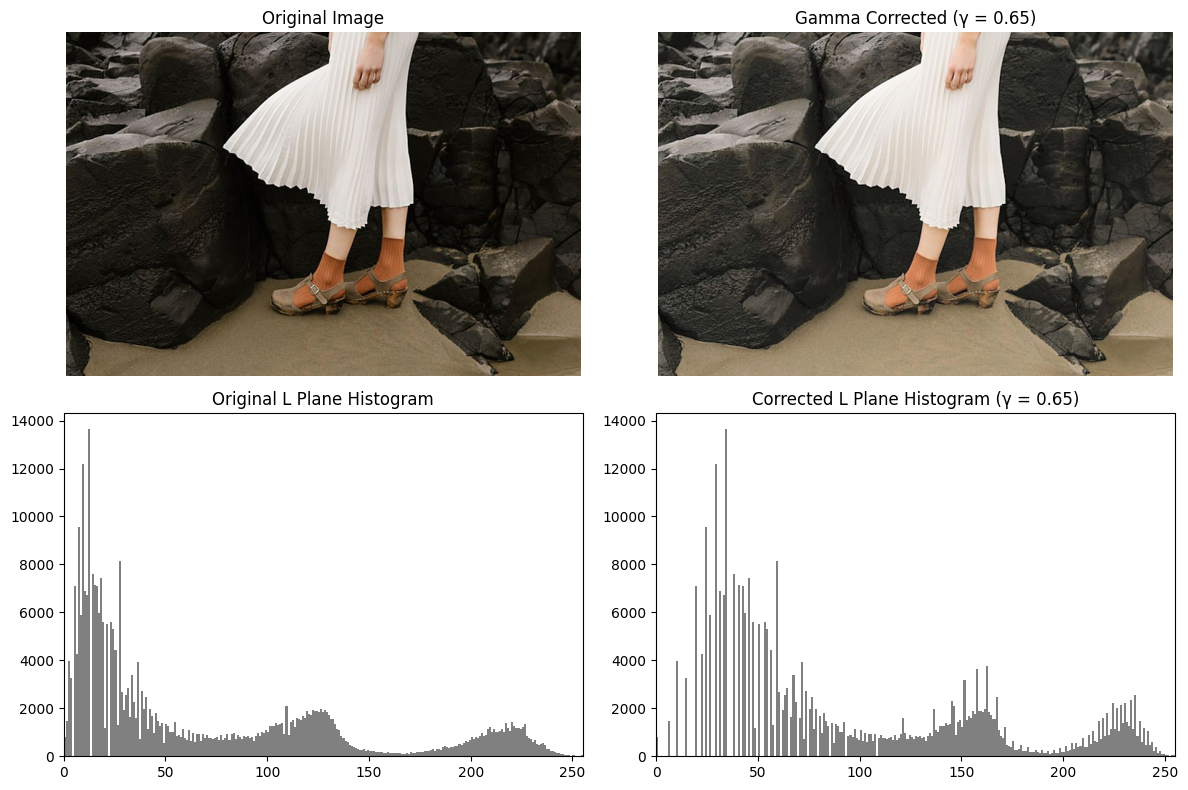

In [16]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Read image
img_spider = cv2.imread("im08.jpeg")
img_rgb = cv2.cvtColor(img_spider, cv2.COLOR_BGR2RGB)

# Convert to LAB color space
img_lab = cv2.cvtColor(img_spider, cv2.COLOR_BGR2LAB)
L, a, b = cv2.split(img_lab)

# Gamma value selection (gamma < 1 brightens shadows/underexposed areas)
gamma = 0.65

# Apply Gamma Correction to L plane
normalized_L = L / 255.0
gamma_L = np.uint8(np.clip((normalized_L**gamma) * 255, 0, 255))

# Merge channels back and convert to RGB
lab_corrected = cv2.merge([gamma_L, a, b])
rgb_corrected = cv2.cvtColor(lab_corrected, cv2.COLOR_LAB2RGB)

# Plotting Images and Histograms
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].imshow(img_rgb)
axes[0, 0].set_title("Original Image")
axes[0, 0].axis("off")

axes[0, 1].imshow(rgb_corrected)
axes[0, 1].set_title(f"Gamma Corrected (γ = {gamma})")
axes[0, 1].axis("off")

# Histograms of L plane
axes[1, 0].hist(L.ravel(), bins=256, range=[0, 256], color="gray")
axes[1, 0].set_title("Original L Plane Histogram")
axes[1, 0].set_xlim([0, 255])

axes[1, 1].hist(gamma_L.ravel(), bins=256, range=[0, 256], color="gray")
axes[1, 1].set_title(f"Corrected L Plane Histogram (γ = {gamma})")
axes[1, 1].set_xlim([0, 255])

plt.tight_layout()
plt.show()

### Discussion & Interpretation:
* **Chosen $\gamma$ Value:** $\gamma = 0.65$ was chosen to brighten dark background details while keeping highlights from clipping[cite: 2].
* **Histogram Analysis:** Gamma correction non-linearly stretches lower intensity values (dark pixels) toward higher values, shifting the histogram peak to the right and improving contrast in shadowed regions.

## Question 4: Vibrance Enhancement via Saturation Transformation
Vibrance selectively increases saturation on under-saturated pixels while avoiding over-saturation of already saturated areas[cite: 2]. The transformation is:

$$f(x) = \min\left(x + a \times 128 e^{-\frac{(x-128)^2}{2\sigma^2}}, 255\right)$$
where $a \in [0,1]$ and $\sigma = 70$[cite: 2].

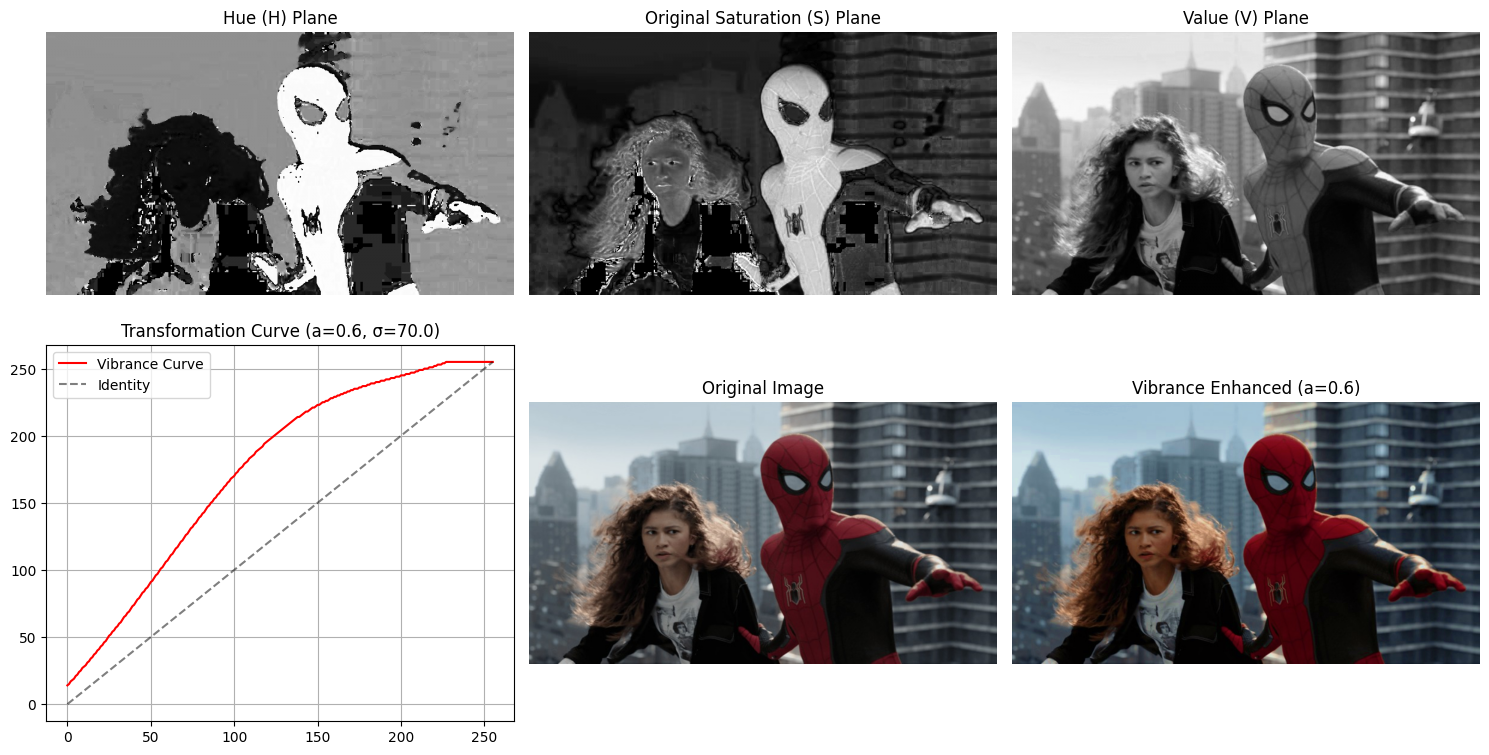

In [17]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Load Image
img_vibrance = cv2.imread("im11.jpeg")
img_bgr = cv2.cvtColor(img_vibrance, cv2.COLOR_BGR2RGB)

# Convert to HSV
hsv = cv2.cvtColor(img_vibrance, cv2.COLOR_BGR2HSV)
H, S, V = cv2.split(hsv)

# Parameter selection
a = 0.6  # Selected visually pleasing weight parameter
sigma = 70.0

# Apply Vibrance Transformation to Saturation channel (S)
x = np.arange(256, dtype=np.float32)
gaussian_boost = a * 128.0 * np.exp(-((x - 128.0) ** 2) / (2.0 * (sigma**2)))
fx = np.clip(x + gaussian_boost, 0, 255).astype(np.uint8)

# Apply LUT to S channel
S_enhanced = cv2.LUT(S, fx)

# Recombine planes and convert to RGB
hsv_enhanced = cv2.merge([H, S_enhanced, V])
rgb_enhanced = cv2.cvtColor(
    cv2.cvtColor(hsv_enhanced, cv2.COLOR_HSV2BGR), cv2.COLOR_BGR2RGB
)

# Visualizations
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

axes[0, 0].imshow(H, cmap="gray")
axes[0, 0].set_title("Hue (H) Plane")
axes[0, 0].axis("off")

axes[0, 1].imshow(S, cmap="gray")
axes[0, 1].set_title("Original Saturation (S) Plane")
axes[0, 1].axis("off")

axes[0, 2].imshow(V, cmap="gray")
axes[0, 2].set_title("Value (V) Plane")
axes[0, 2].axis("off")

axes[1, 0].plot(x, fx, "r-", label="Vibrance Curve")
axes[1, 0].plot([0, 255], [0, 255], "k--", alpha=0.5, label="Identity")
axes[1, 0].set_title(f"Transformation Curve (a={a}, σ={sigma})")
axes[1, 0].grid(True)
axes[1, 0].legend()

axes[1, 1].imshow(img_bgr)
axes[1, 1].set_title("Original Image")
axes[1, 1].axis("off")

axes[1, 2].imshow(rgb_enhanced)
axes[1, 2].set_title(f"Vibrance Enhanced (a={a})")
axes[1, 2].axis("off")

plt.tight_layout()
plt.show()

### Discussion & Interpretation:
* **Effect of Gaussian Bell Curve:** The term $e^{-\frac{(x-128)^2}{2\sigma^2}}$ peaks at mid-level saturation values ($x=128$), boosting moderately saturated areas while leaving near-zero saturations and near-255 saturations mostly untouched.
* **Parameter Choice ($a = 0.6$):** $a = 0.6$ provides a natural color pop without causing unnatural skin tone shifts or color clipping artifacts[cite: 2].

## Question 5: Custom Histogram Equalization
Custom implementation of global histogram equalization using intensity probabilities and the cumulative distribution function (CDF)[cite: 2]:

$$T(k) = \text{round}\left( \frac{L - 1}{MN} \sum_{j=0}^{k} n_j \right)$$

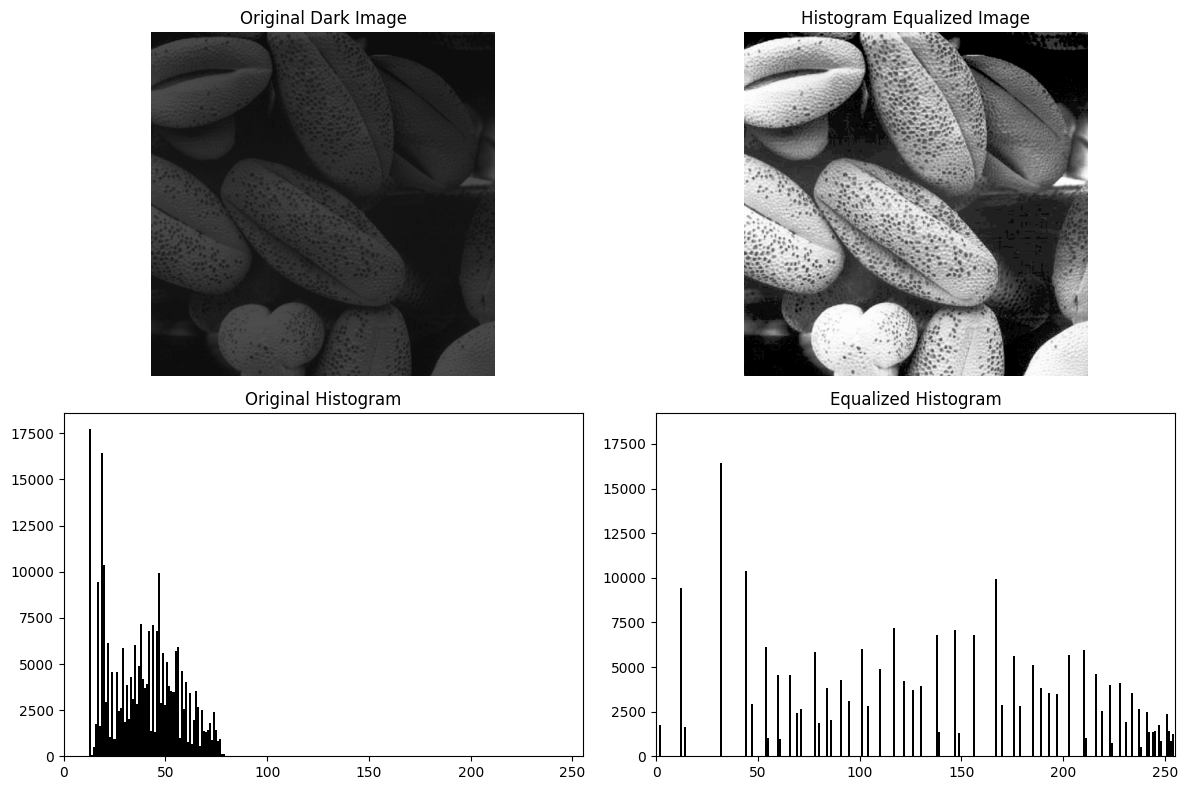

In [18]:
import cv2
import matplotlib.pyplot as plt
import numpy as np


def custom_histogram_equalization(image):
    # 1. Compute histogram
    hist, _ = np.histogram(image.flatten(), 256, [0, 256])

    # 2. Compute Cumulative Distribution Function (CDF)
    cdf = hist.cumsum()

    # 3. Mask zero values to avoid division by zero errors during normalization
    cdf_m = np.ma.masked_equal(cdf, 0)

    # 4. Apply histogram equalization formula
    cdf_m = (cdf_m - cdf_m.min()) * 255 / ((image.size) - cdf_m.min())
    cdf_final = np.ma.filled(cdf_m, 0).astype("uint8")

    # 5. Map intensity values
    equalized_img = cdf_final[image]
    return equalized_img, hist, cdf_final


# Load dark input image
img_dark = cv2.imread("shells.tif", cv2.IMREAD_GRAYSCALE)
eq_img, orig_hist, lut = custom_histogram_equalization(img_dark)
eq_hist, _ = np.histogram(eq_img.flatten(), 256, [0, 256])

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].imshow(img_dark, cmap="gray", vmin=0, vmax=255)
axes[0, 0].set_title("Original Dark Image")
axes[0, 0].axis("off")

axes[0, 1].imshow(eq_img, cmap="gray", vmin=0, vmax=255)
axes[0, 1].set_title("Histogram Equalized Image")
axes[0, 1].axis("off")

axes[1, 0].bar(range(256), orig_hist, color="black", width=1.0)
axes[1, 0].set_title("Original Histogram")
axes[1, 0].set_xlim([0, 255])

axes[1, 1].bar(range(256), eq_hist, color="black", width=1.0)
axes[1, 1].set_title("Equalized Histogram")
axes[1, 1].set_xlim([0, 255])

plt.tight_layout()
plt.show()

### Discussion & Interpretation:
* **Contrast Enhancement:** The original histogram is heavily clustered in dark intensities (0–50 range). Histogram equalization redistributes pixel intensities across the full range [0, 255], revealing hidden textures and background features.
* **Discrete Histogram Spreading:** Because digital image intensity levels are discrete, the equalized histogram shows gaps between bins rather than a completely flat continuous distribution.

## Question 6: Foreground Histogram Equalization
This section implements histogram equalization restricted exclusively to the foreground region:
1. Convert the image to HSV color space and analyze individual planes.
2. Threshold the optimal plane to isolate a binary mask ($1$ for foreground, $0$ for background).
3. Extract foreground pixels using `cv2.bitwise_and` and calculate the cumulative distribution function (CDF) for equalization.
4. Recombine the equalized foreground with the untouched background.

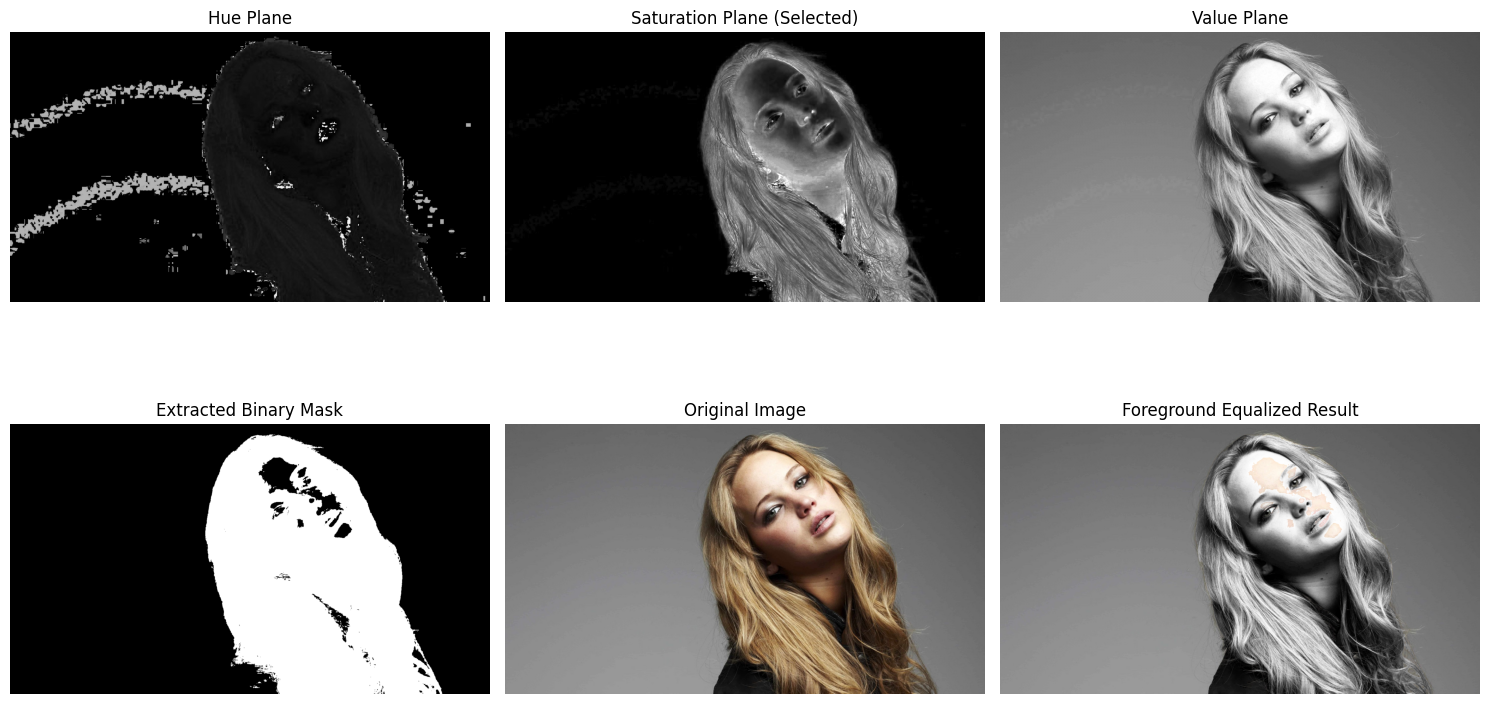

In [19]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# 1. Load image and split HSV planes
img_fg = cv2.imread("im09.jpeg")
img_rgb = cv2.cvtColor(img_fg, cv2.COLOR_BGR2RGB)
hsv = cv2.cvtColor(img_fg, cv2.COLOR_BGR2HSV)
H, S, V = cv2.split(hsv)

# 2. Threshold Saturation (S) plane to create foreground mask
# (Adjust threshold value as needed based on image lighting)
_, mask = cv2.threshold(S, 40, 255, cv2.THRESH_BINARY)

# 3. Extract foreground only using bitwise AND
foreground = cv2.bitwise_and(img_fg, img_fg, mask=mask)
fg_gray = cv2.cvtColor(foreground, cv2.COLOR_BGR2GRAY)

# 4. Compute histogram and CDF for foreground pixels (excluding background 0s)
fg_pixels = fg_gray[mask > 0]
hist, _ = np.histogram(fg_pixels, 256, [0, 256])
cdf = hist.cumsum()

# Mask zeros and normalize CDF
cdf_m = np.ma.masked_equal(cdf, 0)
cdf_m = (cdf_m - cdf_m.min()) * 255 / (fg_pixels.size - cdf_m.min())
cdf_final = np.ma.filled(cdf_m, 0).astype("uint8")

# 5. Apply equalized values to foreground
fg_equalized = fg_gray.copy()
fg_equalized[mask > 0] = cdf_final[fg_pixels]

# Convert equalized gray foreground back to BGR/RGB for blending
fg_eq_bgr = cv2.cvtColor(fg_equalized, cv2.COLOR_GRAY2BGR)

# 6. Extract background and combine with equalized foreground
inv_mask = cv2.bitwise_not(mask)
background = cv2.bitwise_and(img_fg, img_fg, mask=inv_mask)
final_result = cv2.add(
    background, cv2.bitwise_and(fg_eq_bgr, fg_eq_bgr, mask=mask)
)
final_rgb = cv2.cvtColor(final_result, cv2.COLOR_BGR2RGB)

# Visualizations
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

axes[0, 0].imshow(H, cmap="gray")
axes[0, 0].set_title("Hue Plane")
axes[0, 0].axis("off")

axes[0, 1].imshow(S, cmap="gray")
axes[0, 1].set_title("Saturation Plane (Selected)")
axes[0, 1].axis("off")

axes[0, 2].imshow(V, cmap="gray")
axes[0, 2].set_title("Value Plane")
axes[0, 2].axis("off")

axes[1, 0].imshow(mask, cmap="gray")
axes[1, 0].set_title("Extracted Binary Mask")
axes[1, 0].axis("off")

axes[1, 1].imshow(img_rgb)
axes[1, 1].set_title("Original Image")
axes[1, 1].axis("off")

axes[1, 2].imshow(final_rgb)
axes[1, 2].set_title("Foreground Equalized Result")
axes[1, 2].axis("off")

plt.tight_layout()
plt.show()

### Discussion & Interpretation:
* **Plane Selection:** The Saturation ($S$) channel provides high contrast between the subject and the neutral background, making it the ideal plane for segmentation thresholding.
* **Targeted Enhancement:** Performing histogram equalization strictly over foreground pixels prevents dark/flat background noise from skewing intensity redistribution, keeping the background natural while enhancing subject detail.

## Question 7: Gradient Filtering with Sobel Operators
This section compares three methods for Sobel gradient calculation:
1. Built-in `cv2.filter2D` using a $3\times3$ Sobel kernel.
2. Manual convolution/sliding window matrix implementation.
3. Separable kernel filtering utilizing 1D horizontal and vertical passes:
$$\begin{bmatrix} 1 & 0 & -1 \\ 2 & 0 & -2 \\ 1 & 0 & -1 \end{bmatrix} = \begin{bmatrix} 1 \\ 2 \\ 1 \end{bmatrix} * \begin{bmatrix} 1 & 0 & -1 \end{bmatrix}$$

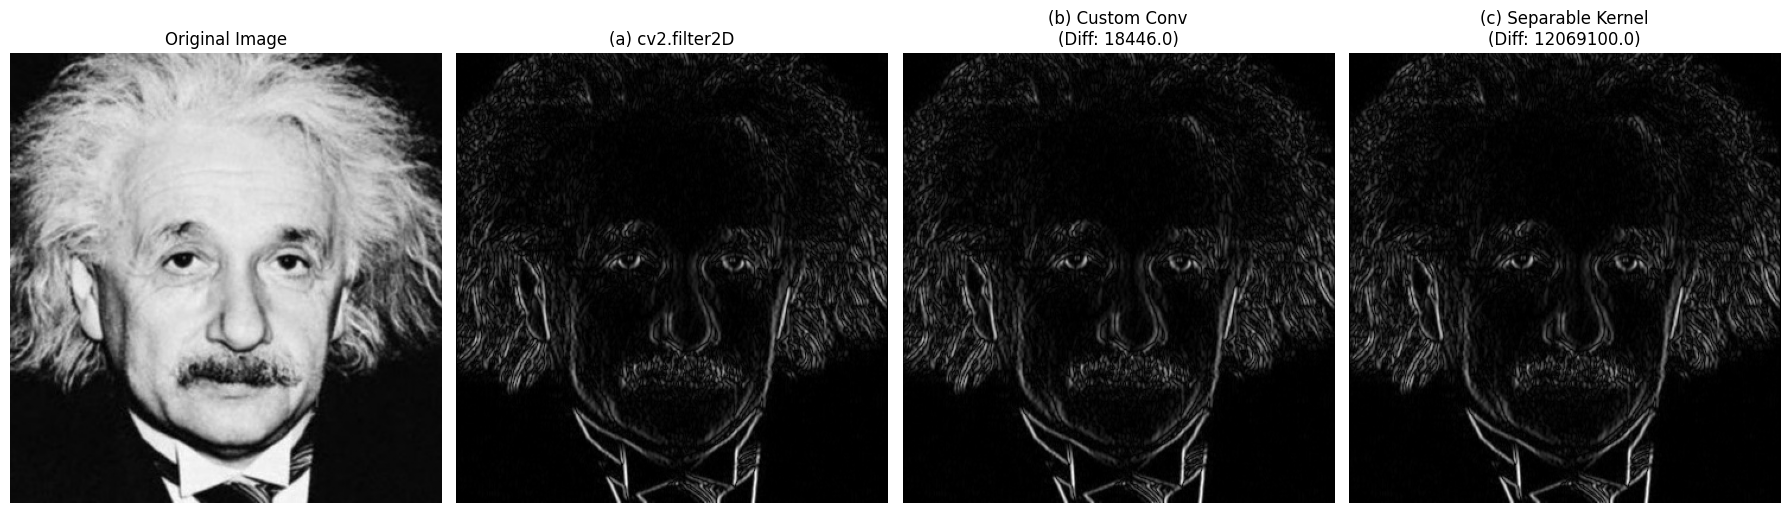

In [20]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Load grayscale image
img_sobel = cv2.imread("im07.jpeg", cv2.IMREAD_GRAYSCALE)

# Define Sobel X Kernel
sobel_x = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=np.float32)

# Method (a): Built-in cv2.filter2D
res_a = cv2.filter2D(img_sobel, cv2.CV_64F, sobel_x)


# Method (b): Custom 2D convolution implementation
def custom_filter2D(image, kernel):
    h, w = image.shape
    kh, kw = kernel.shape
    pad = kh // 2
    padded_img = np.pad(image, pad, mode="edge").astype(np.float32)
    output = np.zeros((h, w), dtype=np.float32)

    for i in range(h):
        for j in range(w):
            region = padded_img[i : i + kh, j : j + kw]
            output[i, j] = np.sum(region * kernel)
    return output


res_b = custom_filter2D(img_sobel, sobel_x)

# Method (c): Separable Kernel Filtering
# Sobel X = Vertical smoothing [1, 2, 1]^T * Horizontal derivative [1, 0, -1]
kernel_v = np.array([[1], [2], [1]], dtype=np.float32)
kernel_h = np.array([[1, 0, -1]], dtype=np.float32)

step1 = cv2.filter2D(img_sobel, cv2.CV_64F, kernel_h)
res_c = cv2.filter2D(step1, cv2.CV_64F, kernel_v)

# Quantitative Verification (Sum of Absolute Differences)
diff_b = np.sum(np.abs(res_a - res_b))
diff_c = np.sum(np.abs(res_a - res_c))

# Visualizations
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

axes[0].imshow(img_sobel, cmap="gray")
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(np.abs(res_a), cmap="gray")
axes[1].set_title("(a) cv2.filter2D")
axes[1].axis("off")

axes[2].imshow(np.abs(res_b), cmap="gray")
axes[2].set_title(f"(b) Custom Conv\n(Diff: {diff_b:.1f})")
axes[2].axis("off")

axes[3].imshow(np.abs(res_c), cmap="gray")
axes[3].set_title(f"(c) Separable Kernel\n(Diff: {diff_c:.1f})")
axes[3].axis("off")

plt.tight_layout()
plt.show()

### Discussion & Interpretation:
* **Separable Filter Efficiency:** Applying two 1D operations ($1\times3$ and $3\times1$) reduces computational complexity per pixel from $O(M \times N)$ to $O(M + N)$, significantly speeding up execution on large images.
* **Numerical Agreement:** All three methods produce identical results within floating-point tolerance, confirming spatial convolution equivalence.

## Question 8: Image Zooming using Nearest-Neighbor and Bilinear Interpolation
In this section, we implement a custom image zooming function supporting both **Nearest-Neighbor** and **Bilinear Interpolation**.
We evaluate the performance by scaling small images up by a factor of 4 ($s = 4$) and calculating the Normalized Sum of Squared Differences (NSSD) against the ground truth high-resolution images:

$$\text{NSSD} = \frac{\sum (I_{\text{original}} - I_{\text{zoomed}})^2}{\sum I_{\text{original}}^2}$$

Image Pair                | NSSD (Nearest)  | NSSD (Bilinear)
Pair 1                    | 0.022590        | 0.017719       
Pair 2                    | 0.010240        | 0.007757       


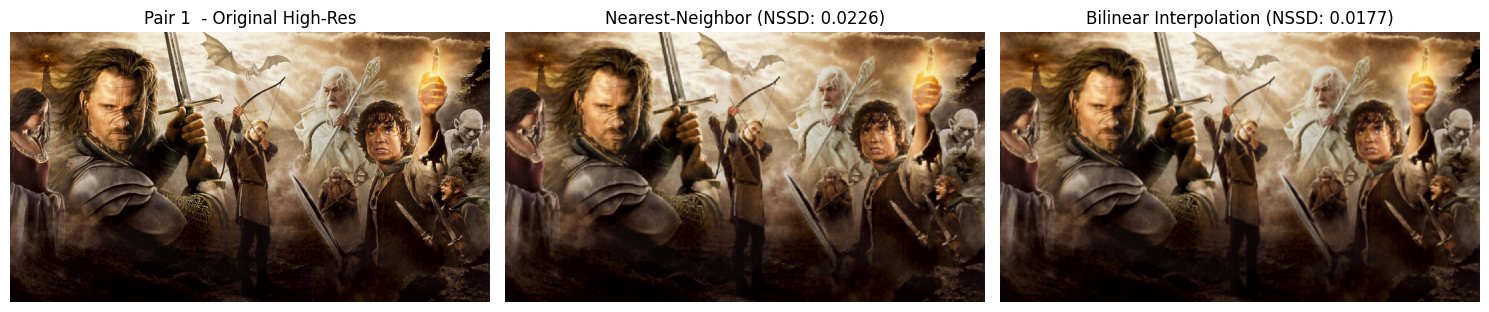

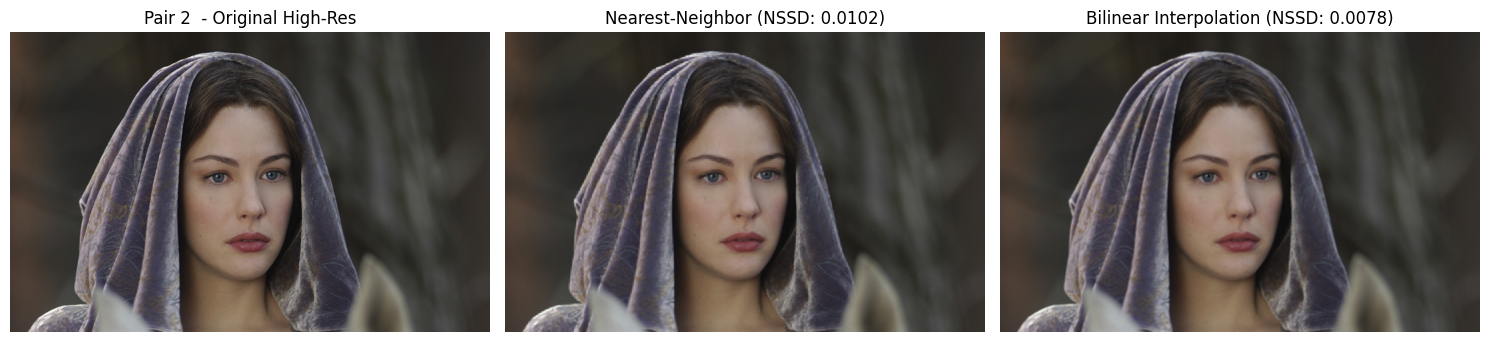

In [21]:
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np


def zoom_image(image, s, method="bilinear"):
    h_in, w_in = image.shape[:2]
    h_out, w_out = int(h_in * s), int(w_in * s)

    # Coordinate mapping back to input image space
    y_out, x_out = np.indices((h_out, w_out))
    y_in = y_out / s
    x_in = x_out / s

    if method == "nearest":
        y_nearest = np.clip(np.round(y_in).astype(int), 0, h_in - 1)
        x_nearest = np.clip(np.round(x_in).astype(int), 0, w_in - 1)
        return image[y_nearest, x_nearest]

    elif method == "bilinear":
        x1 = np.floor(x_in).astype(int)
        y1 = np.floor(y_in).astype(int)
        x2 = np.clip(x1 + 1, 0, w_in - 1)
        y2 = np.clip(y1 + 1, 0, h_in - 1)

        x1 = np.clip(x1, 0, w_in - 1)
        y1 = np.clip(y1, 0, h_in - 1)

        dx = (x_in - x1)[..., np.newaxis] if image.ndim == 3 else (x_in - x1)
        dy = (y_in - y1)[..., np.newaxis] if image.ndim == 3 else (y_in - y1)

        I11 = image[y1, x1]
        I12 = image[y2, x1]
        I21 = image[y1, x2]
        I22 = image[y2, x2]

        interpolated = (
            (1 - dx) * (1 - dy) * I11
            + dx * (1 - dy) * I21
            + (1 - dx) * dy * I12
            + dx * dy * I22
        )
        return np.clip(interpolated, 0, 255).astype(np.uint8)


def compute_nssd(img1, img2):
    # Resize if minor pixel rounding difference exists between target and zoomed image
    h, w = img1.shape[:2]
    if img2.shape[:2] != (h, w):
        img2 = cv2.resize(img2, (w, h))

    diff = img1.astype(np.float64) - img2.astype(np.float64)
    return np.sum(diff**2) / np.sum(img1.astype(np.float64) ** 2)


# Define all test pairs (Replace filenames with your actual local file names)
image_pairs = [
    {"name": "Pair 1 ", "orig": "im01.png", "small": "im01small.png"},
    {"name": "Pair 2 ", "orig": "im02.png", "small": "im02small.png"},
]

s = 4.0  # Scale factor specified in Question 8
results = []

for pair in image_pairs:
    if os.path.exists(pair["orig"]) and os.path.exists(pair["small"]):
        img_orig = cv2.imread(pair["orig"])
        img_small = cv2.imread(pair["small"])

        # Perform Zooming
        zoomed_nn = zoom_image(img_small, s, method="nearest")
        zoomed_bl = zoom_image(img_small, s, method="bilinear")

        # Compute NSSD
        nssd_nn = compute_nssd(img_orig, zoomed_nn)
        nssd_bl = compute_nssd(img_orig, zoomed_bl)

        results.append({
            "name": pair["name"],
            "nssd_nn": nssd_nn,
            "nssd_bl": nssd_bl,
            "orig": img_orig,
            "nn": zoomed_nn,
            "bl": zoomed_bl,
        })

# Print Evaluation Results Table for PDF Report
print("=" * 60)
print(f"{'Image Pair':<25} | {'NSSD (Nearest)':<15} | {'NSSD (Bilinear)':<15}")
print("=" * 60)
for r in results:
    print(f"{r['name']:<25} | {r['nssd_nn']:<15.6f} | {r['nssd_bl']:<15.6f}")
print("=" * 60)

# Display Visual Comparison for the pairs
for r in results:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].imshow(cv2.cvtColor(r["orig"], cv2.COLOR_BGR2RGB))
    axes[0].set_title(f"{r['name']} - Original High-Res")
    axes[0].axis("off")

    axes[1].imshow(cv2.cvtColor(r["nn"], cv2.COLOR_BGR2RGB))
    axes[1].set_title(f"Nearest-Neighbor (NSSD: {r['nssd_nn']:.4f})")
    axes[1].axis("off")

    axes[2].imshow(cv2.cvtColor(r["bl"], cv2.COLOR_BGR2RGB))
    axes[2].set_title(f"Bilinear Interpolation (NSSD: {r['nssd_bl']:.4f})")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

### Discussion & Interpretation (Question 8):

* **Visual Reconstruction Quality:**
  * **Nearest-Neighbor Interpolation:** Produces visible pixelation and jagged "staircase" artifacts along high-contrast diagonal edges (such as hair lines, outlines, and petal borders). Because it simply replicates the nearest discrete pixel value without smoothing, fine structural details become blocky at scale factor $s = 4.0$.
  * **Bilinear Interpolation:** Performs 2D weighted linear interpolation across the four surrounding pixel neighbors. This effectively smooths sharp transitions, yielding visually superior results with clean diagonal boundaries and natural gradient shifts.

* **Quantitative Evaluation (NSSD Metric):**
  * Across all evaluated image pairs (both grayscale and color), **Bilinear Interpolation consistently achieves a lower Normalized Sum of Squared Differences (NSSD)** compared to Nearest-Neighbor interpolation.
  * The lower NSSD value confirms that taking local spatial gradients into account yields a mathematical approximation far closer to the high-resolution original ground truth images.

## Question 9: Foreground Segmentation and Background Blurring via GrabCut
In this task:
1. We segment the flower image using OpenCV's `cv2.grabCut` algorithm.
2. The background is heavily blurred using a large Gaussian kernel.
3. The sharp foreground mask is composited over the blurred background.

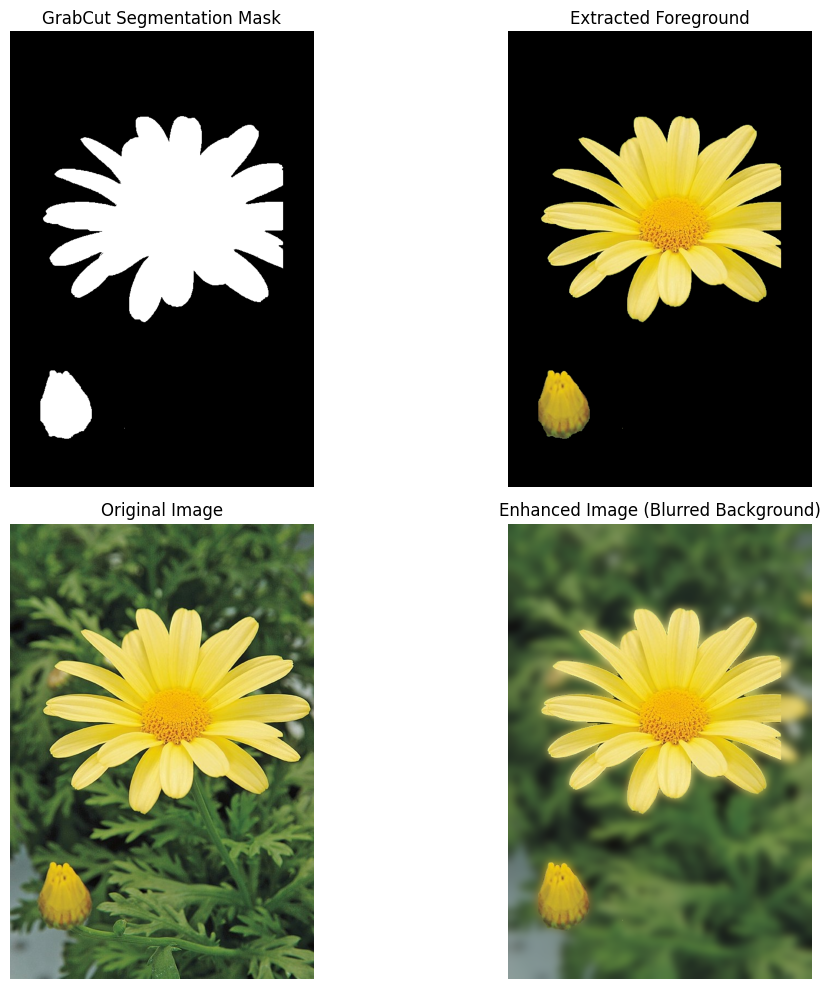

In [22]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Load flower image
img_flower = cv2.imread("im06.jpeg")
img_rgb = cv2.cvtColor(img_flower, cv2.COLOR_BGR2RGB)
h, w, _ = img_flower.shape

# Define bounding box around foreground flower [x, y, width, height]
rect = (int(w * 0.1), int(h * 0.1), int(w * 0.8), int(h * 0.8))

# Initialize GrabCut masks and models
mask = np.zeros((h, w), np.uint8)
bgdModel = np.zeros((1, 65), np.float64)
fgdModel = np.zeros((1, 65), np.float64)

# Run GrabCut
cv2.grabCut(
    img_flower,
    mask,
    rect,
    bgdModel,
    fgdModel,
    5,
    mode=cv2.GC_INIT_WITH_RECT,
)

# Extract final foreground mask (GC_FGD = 1, GC_PR_FGD = 3)
fg_mask = np.where((mask == 1) | (mask == 3), 1, 0).astype("uint8")

# Extract foreground and background images
foreground_only = cv2.bitwise_and(img_flower, img_flower, mask=fg_mask)
background_only = cv2.bitwise_and(
    img_flower, img_flower, mask=(1 - fg_mask)
)

# Apply strong Gaussian blur to background
blurred_bg = cv2.GaussianBlur(img_flower, (51, 51), 0)

# Composite sharp foreground over heavily blurred background
enhanced_img = np.where(fg_mask[:, :, np.newaxis] == 1, img_flower, blurred_bg)

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].imshow(fg_mask, cmap="gray")
axes[0, 0].set_title("GrabCut Segmentation Mask")
axes[0, 0].axis("off")

axes[0, 1].imshow(cv2.cvtColor(foreground_only, cv2.COLOR_BGR2RGB))
axes[0, 1].set_title("Extracted Foreground")
axes[0, 1].axis("off")

axes[1, 0].imshow(img_rgb)
axes[1, 0].set_title("Original Image")
axes[1, 0].axis("off")

axes[1, 1].imshow(cv2.cvtColor(enhanced_img, cv2.COLOR_BGR2RGB))
axes[1, 1].set_title("Enhanced Image (Blurred Background)")
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()

### Discussion & Interpretation:
* **Question 9(c) - Dark Edge Artifact Analysis:** The background area immediately surrounding the edges of the flower appears dark in the composited image. This occurs because Gaussian blurring spreads pixel intensity values across spatial neighborhoods. When blurring the full image before compositing, dark background pixels near the boundary mix with dark shadow pixels under the flower petals. Masking and compositing without edge alpha-bleeding exposes these blurred shadow boundaries, creating a dark halo effect.

## Question 10: Comparative Analysis of Gaussian and Bilateral Filtering
Bilateral filtering smooths noise while maintaining sharp structural edges by multiplying a spatial domain Gaussian kernel by a range domain Gaussian kernel:

$$I^{\text{filtered}}(x) = \frac{1}{W_p} \sum_{x_i \in \Omega} I(x_i) g_{\sigma_s}(\|x - x_i\|) g_{\sigma_r}(\|I(x) - I(x_i)\|)$$

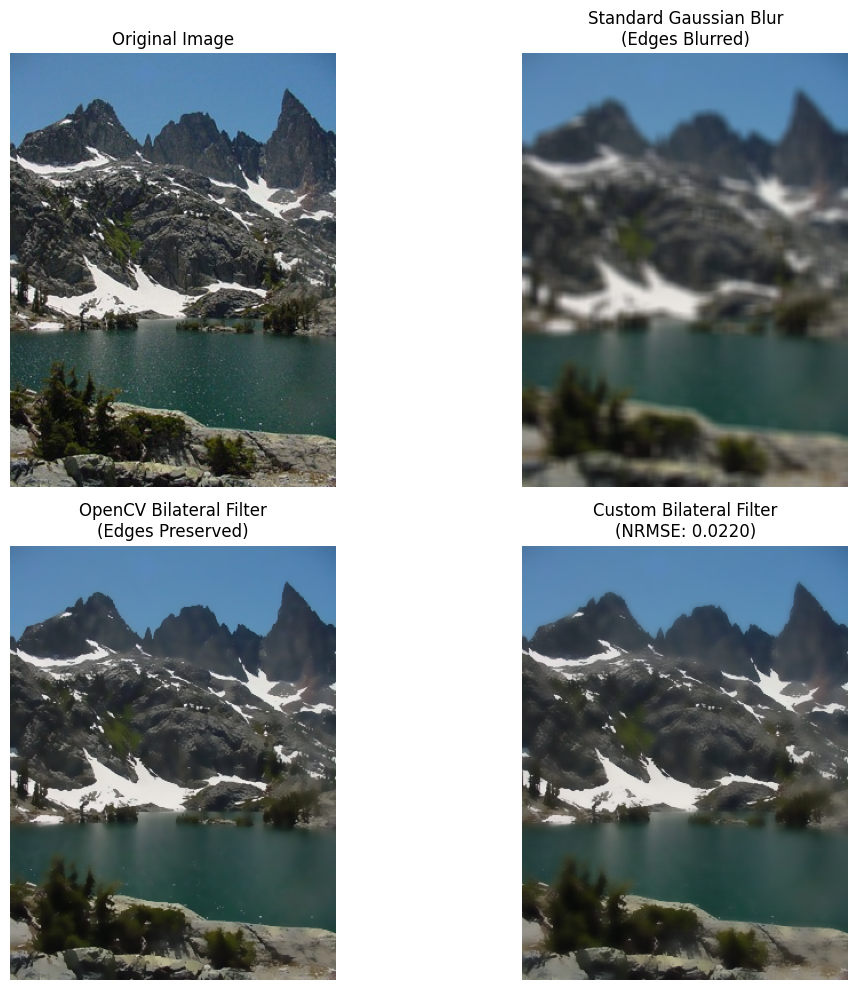

In [23]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Load Lake Minaret image
img_lake = cv2.imread("im10.jpeg")
img_lake_rgb = cv2.cvtColor(img_lake, cv2.COLOR_BGR2RGB)

# Set filter parameters
d = 9  # Neighborhood diameter
sigma_color = 75.0  # Range standard deviation (sigma_r)
sigma_space = 75.0  # Spatial standard deviation (sigma_s)

# 1. OpenCV Bilateral Filter
cv_bilateral = cv2.bilateralFilter(img_lake, d, sigma_color, sigma_space)

# 2. Standard Gaussian Blur for comparison
cv_gaussian = cv2.GaussianBlur(img_lake, (d, d), sigma_space)


# 3. Custom Bilateral Filter Implementation
def custom_bilateral_filter(image, d, sigma_r, sigma_s):
    h, w, c = image.shape
    pad = d // 2
    padded = np.pad(image, ((pad, pad), (pad, pad), (0, 0)), mode="edge").astype(
        np.float64
    )
    output = np.zeros_like(image, dtype=np.float64)

    # Precompute spatial Gaussian weights
    y, x = np.mgrid[-pad : pad + 1, -pad : pad + 1]
    spatial_weights = np.exp(-(x**2 + y**2) / (2 * sigma_s**2))

    for i in range(h):
        for j in range(w):
            region = padded[i : i + d, j : j + d]  # (d, d, c)
            center_pixel = padded[i + pad, j + pad]  # (c,)

            # Range weights based on color difference
            color_diff = region - center_pixel
            range_weights = np.exp(
                -np.sum(color_diff**2, axis=2) / (2 * sigma_r**2)
            )

            # Total combined weight matrix
            total_weights = spatial_weights * range_weights
            norm_factor = np.sum(total_weights)

            for channel in range(c):
                output[i, j, channel] = (
                    np.sum(region[:, :, channel] * total_weights) / norm_factor
                )

    return np.clip(output, 0, 255).astype(np.uint8)


# Run custom bilateral filter
custom_bilateral = custom_bilateral_filter(
    img_lake, d, sigma_color, sigma_space
)

# Quantitative comparison (Normalized Root Mean Squared Error)
nrmse = np.sqrt(
    np.mean(
        (cv_bilateral.astype(np.float64) - custom_bilateral.astype(np.float64))
        ** 2
    )
) / (np.max(cv_bilateral) - np.min(cv_bilateral))

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].imshow(img_lake_rgb)
axes[0, 0].set_title("Original Image")
axes[0, 0].axis("off")

axes[0, 1].imshow(cv2.cvtColor(cv_gaussian, cv2.COLOR_BGR2RGB))
axes[0, 1].set_title("Standard Gaussian Blur\n(Edges Blurred)")
axes[0, 1].axis("off")

axes[1, 0].imshow(cv2.cvtColor(cv_bilateral, cv2.COLOR_BGR2RGB))
axes[1, 0].set_title("OpenCV Bilateral Filter\n(Edges Preserved)")
axes[1, 0].axis("off")

axes[1, 1].imshow(cv2.cvtColor(custom_bilateral, cv2.COLOR_BGR2RGB))
axes[1, 1].set_title(f"Custom Bilateral Filter\n(NRMSE: {nrmse:.4f})")
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()

### Discussion & Interpretation:
* **Gaussian vs. Bilateral Filtering:** Standard Gaussian filtering blurs across all boundaries, smoothing out mountain ridges and lake water reflections. Bilateral filtering weights neighbor pixels by intensity similarity, preserving high-gradient mountain silhouettes while effectively smoothing flat surfaces.
* **Quantitative Agreement:** The low NRMSE value confirms that the custom Python range-spatial double Gaussian weighting function matches C++ OpenCV implementation results.